In [1]:
#load the best models from the checkpoints folder

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical 
from tensorflow.keras.models import load_model, Model
import json
import helper
import plotly.express as px

AVERAGED = 1

2024-01-25 20:41:45.479179: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def get_model(model_id):
    params = []
    #load the json from params.json
    with open('params.json') as json_file:
        params = json.load(json_file)
    params = params[model_id]
    print(params)
    model = load_model('checkpoints/best_model_{}.h5'.format(model_id), compile=False)
    return model, params

In [3]:
#load the data
def avg(group, group_size): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res
def get_data(model, params,averaged):
    group_size = params['group_size'] if averaged == None else averaged
    data = pd.read_hdf("../../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
    #print all the columns
    ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
    data = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                        (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]
    data = data.groupby(['Peptide', 'Time', 'Replicate', 'Concentration']).apply(avg, group_size=group_size)
    antigen = list(data.index.get_level_values('Peptide'))
    times = list(data.index.get_level_values('Time'))
    concentration = list(data.index.get_level_values('Concentration'))
    scaling_factor = 1024/(params['output_range'][1]-params['output_range'][0])
    X = np.array(data.values)/scaling_factor + params['output_range'][0]
    y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
    y = to_categorical(y)


    extractor = Model(inputs=model.inputs,
                        outputs=model.get_layer("Bottleneck").output)
    embedding = np.array(extractor(X))
    output = np.argmax(y,axis=1)
    ANTIGENS = ["null", "E1", "G4", "V4", "T4", "Q4", "A2", "N4"]
    output = np.array(ANTIGENS)[output]
    num_embedding_dimensions = embedding.shape[1]
    df = pd.DataFrame(embedding, columns=['Dimension '+str(i+1) for i in range(num_embedding_dimensions)])
    df["Antigen"] = output
    df["Time"] = times
    df["Concentration"] = concentration
    for i in range(len(data.columns)):
        df[data.columns[i]] = X[:,i]
    return df, data.columns

In [4]:
def get_plots(df, markers,params,group_size):
    plt.figure(figsize=(15, 15))
    plt.suptitle("Group size {}, trained on group size {}".format(group_size,params['group_size']), fontsize=16)
    for i in range(len(markers)):
        plt.subplot(6, 5, i + 1)
        plt.scatter(df['Dimension 1'], df['Dimension 2'], c=df[markers[i]], s=0.005)
        plt.xlabel('Dimension 1')
        plt.ylabel('Dimension 2')
        plt.title('2D Plot of ' + markers[i])
        plt.colorbar(label=markers[i])
    #add one last one for time
    plt.subplot(6, 5, len(markers) + 1)
    plt.scatter(df['Dimension 1'], df['Dimension 2'], c=df['Time'], s=0.005)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title('2D Plot of Time')
    plt.colorbar(label='Time')
    plt.tight_layout()  # Adjust subplot parameters to give specified padding
    plt.show()

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


2024-01-25 20:41:48.067035: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-01-25 20:41:48.067615: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


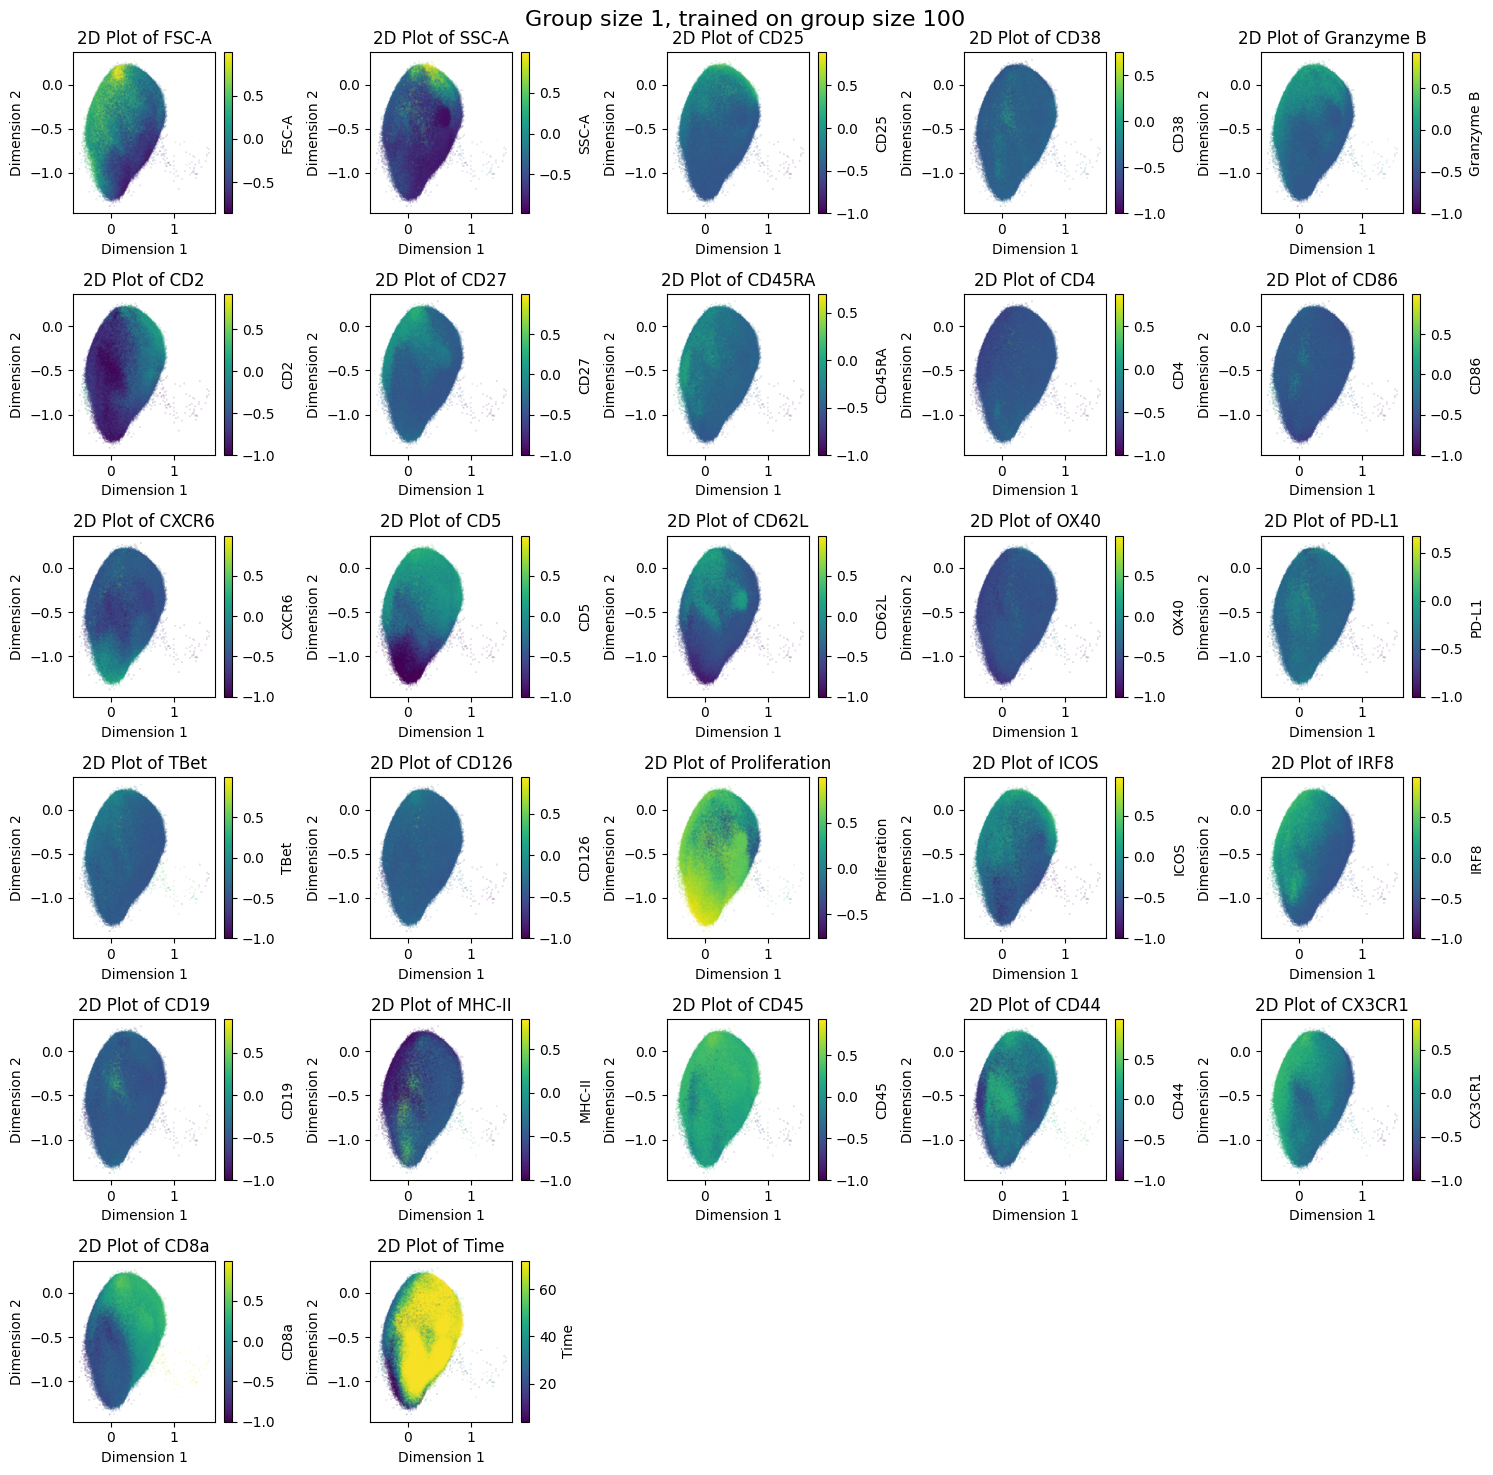

{'group_size': 25, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 106}


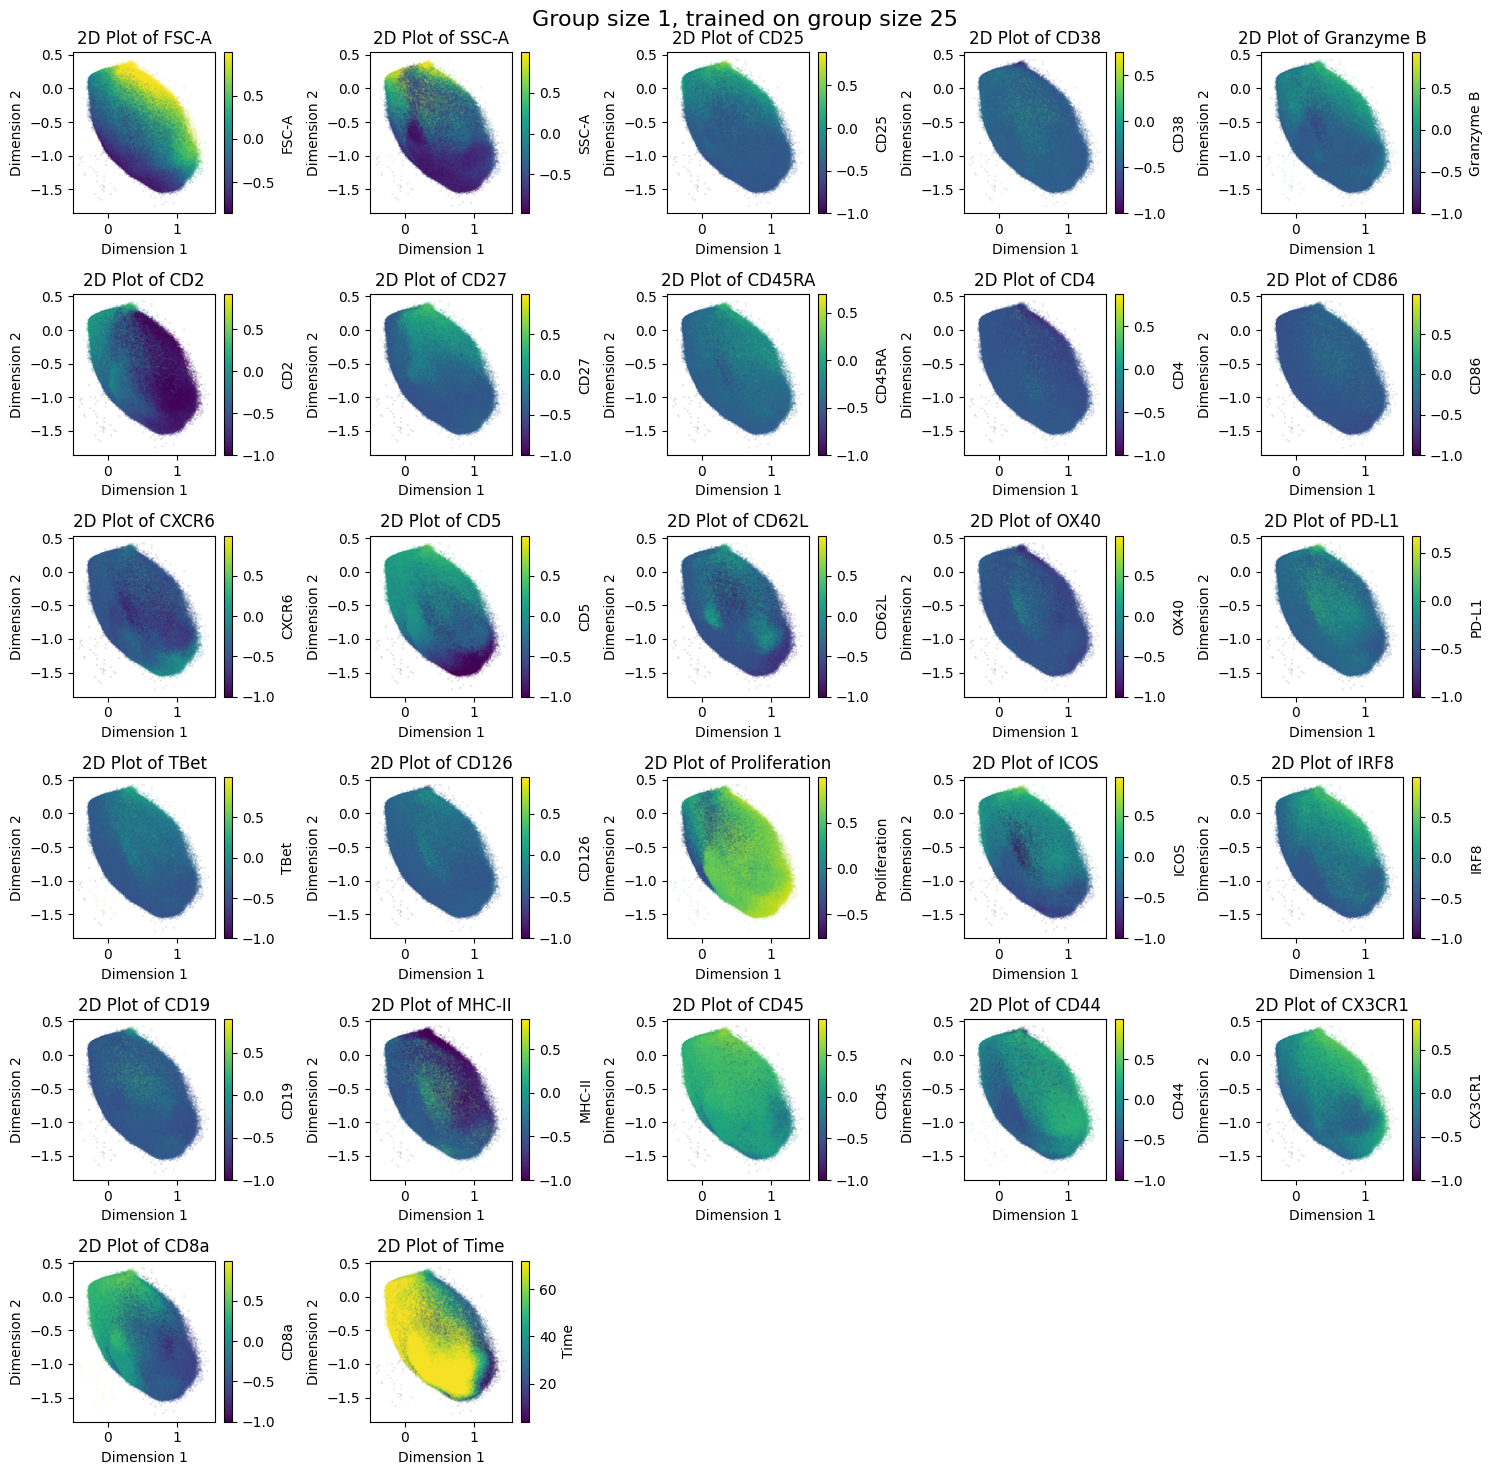

{'group_size': 10, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 70}


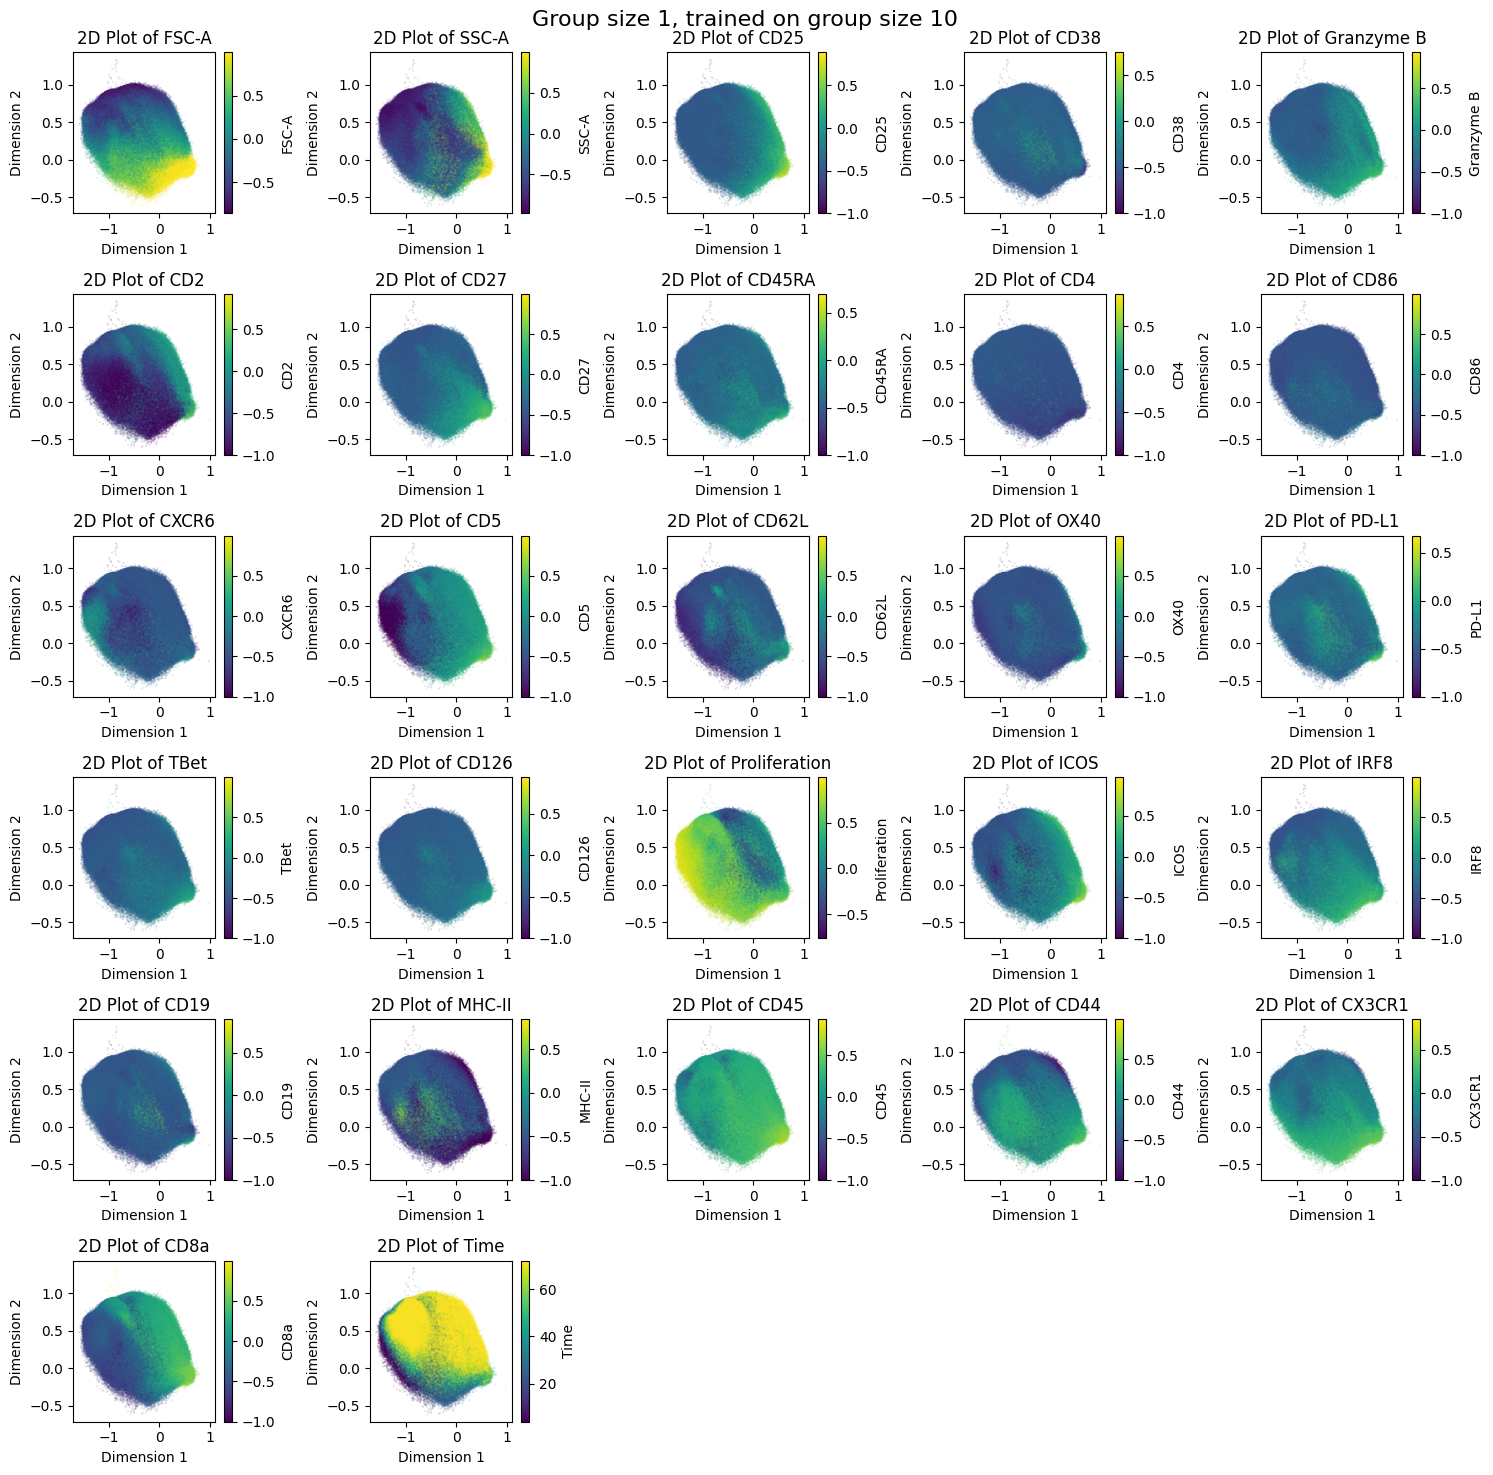

{'group_size': 1, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 35}


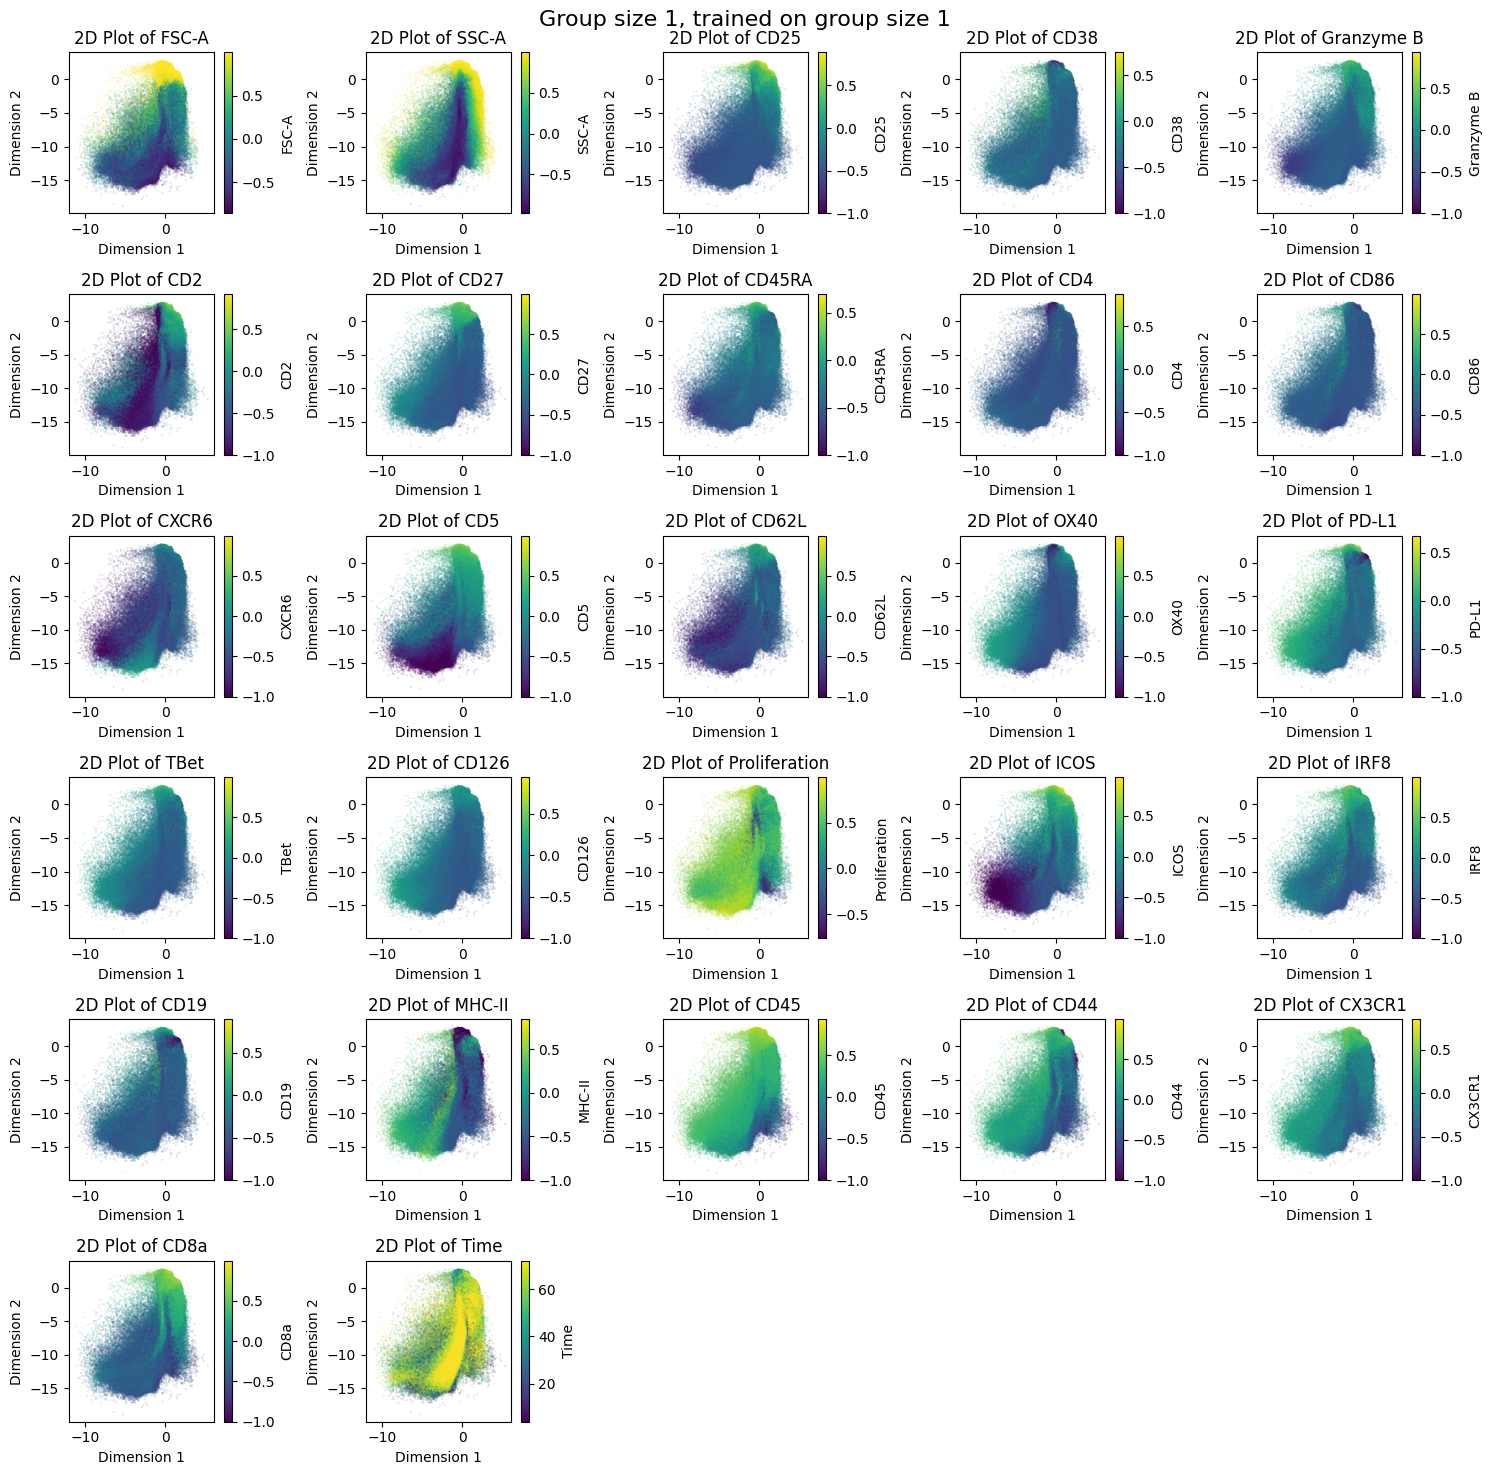

In [5]:
for model_id in [143, 106, 70, 35]:
    model, params = get_model(model_id)
    df, markers = get_data(model, params,AVERAGED)
    get_plots(df, markers,params,AVERAGED)